In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from sklearn.tree import (DecisionTreeClassifier,
                          plot_tree, export_text)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay,
                              roc_curve,
                              roc_auc_score,
                              accuracy_score,
                              f1_score)
import warnings
warnings.filterwarnings('ignore')

# ── Load credentials ─────────────────────────────────
load_dotenv(r"C:\Users\Administrator\Desktop\kenya_road_safety_project\.env")

# ── Plot style ───────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Paths ────────────────────────────────────────────
BASE_DIR   = r"C:\Users\Administrator\Desktop\kenya_road_safety_project"
CLEAN_DATA = os.path.join(BASE_DIR, "data", "cleaned", "accidents_clean.csv")
VISUALS    = os.path.join(BASE_DIR, "visuals")
os.makedirs(VISUALS, exist_ok=True)

# ── Database connection ──────────────────────────────
connection_url = URL.create(
    drivername = "postgresql+psycopg2",
    username   = os.getenv("DB_USER"),
    password   = os.getenv("DB_PASSWORD"),
    host       = os.getenv("DB_HOST"),
    port       = int(os.getenv("DB_PORT")),
    database   = os.getenv("DB_NAME")
)
engine = create_engine(connection_url)

# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (1119, 20)


In [2]:
# ── Fill nulls before encoding ───────────────────────
df['county']          = df['county'].fillna('Unknown')
df['cause_code']      = df['cause_code'].fillna('Unknown')
df['victim_category'] = df['victim_category'].fillna('Unknown')
df['time_of_day']     = df['time_of_day'].fillna('Unknown')
df['road']            = df['road'].fillna('Unknown')
df['hour']            = df['hour'].fillna(0)
df['num_victims']     = df['num_victims'].fillna(1)

# ── Encode categorical columns ───────────────────────
le_county  = LabelEncoder()
le_cause   = LabelEncoder()
le_victim  = LabelEncoder()
le_time    = LabelEncoder()
le_road    = LabelEncoder()

df['county_encoded']  = le_county.fit_transform(df['county'])
df['cause_encoded']   = le_cause.fit_transform(
                         df['cause_code'].astype(str))
df['victim_encoded']  = le_victim.fit_transform(df['victim_category'])
df['time_encoded']    = le_time.fit_transform(df['time_of_day'])
df['road_encoded']    = le_road.fit_transform(df['road'])

print("Encoding complete")
print(f"County categories  : {len(le_county.classes_)}")
print(f"Cause categories   : {len(le_cause.classes_)}")
print(f"Victim categories  : {len(le_victim.classes_)}")
print(f"Road categories    : {len(le_road.classes_)}")

Encoding complete
County categories  : 43
Cause categories   : 74
Victim categories  : 7
Road categories    : 716


In [3]:
# ── Define features and target ───────────────────────
features = [
    'hour',
    'county_encoded',
    'cause_encoded',
    'victim_encoded',
    'time_encoded',
    'road_encoded',
    'num_victims'
]

feature_names = [
    'Hour of Day',
    'County',
    'Cause Code',
    'Victim Type',
    'Time of Day',
    'Road',
    'Number of Victims'
]

df_model = df[features + ['is_fatal']].dropna()

X = df_model[features]
y = df_model['is_fatal']

# ── Train test split ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print("="*55)
print("DATASET SUMMARY")
print("="*55)
print(f"Total records     : {len(df_model)}")
print(f"Training samples  : {len(X_train)}")
print(f"Testing samples   : {len(X_test)}")
print(f"Fatal rate        : {y.mean()*100:.1f}%")

DATASET SUMMARY
Total records     : 1119
Training samples  : 895
Testing samples   : 224
Fatal rate        : 14.2%


In [4]:
# ── Train 3 versions to demonstrate overfitting ──────

# Version 1 — Shallow tree (simple, most explainable)
dt_shallow = DecisionTreeClassifier(
    max_depth    = 3,
    random_state = 42,
    criterion    = 'gini',
    class_weight = 'balanced'
)
dt_shallow.fit(X_train, y_train)

# Version 2 — Medium tree (balanced depth)
dt_medium = DecisionTreeClassifier(
    max_depth    = 5,
    random_state = 42,
    criterion    = 'gini',
    class_weight = 'balanced'
)
dt_medium.fit(X_train, y_train)

# Version 3 — Full tree (no depth limit — overfits)
dt_full = DecisionTreeClassifier(
    random_state = 42,
    criterion    = 'gini',
    class_weight = 'balanced'
)
dt_full.fit(X_train, y_train)

# ── Compare all three ────────────────────────────────
print("="*60)
print("COMPARISON — THREE TREE DEPTHS")
print("="*60)
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Overfit?':>10}")
print("-"*60)

for name, model in [
    ('Shallow Tree (depth=3)', dt_shallow),
    ('Medium Tree  (depth=5)', dt_medium),
    ('Full Tree    (no limit)', dt_full)
]:
    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test,  y_test)
    overfit   = "YES" if train_acc - test_acc > 0.1 else "No"
    print(f"{name:<25} {train_acc:>10.3f} {test_acc:>10.3f} "
          f"{overfit:>10}")

COMPARISON — THREE TREE DEPTHS
Model                      Train Acc   Test Acc   Overfit?
------------------------------------------------------------
Shallow Tree (depth=3)         0.742      0.679         No
Medium Tree  (depth=5)         0.789      0.714         No
Full Tree    (no limit)        1.000      0.786        YES


In [5]:
# Medium tree is our primary model
# Best balance between accuracy and interpretability

y_pred       = dt_medium.predict(X_test)
y_pred_proba = dt_medium.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_pred_proba)

print("="*55)
print("EVALUATION — MEDIUM TREE (depth=5)")
print("="*55)
print(f"Accuracy   : {acc:.4f}  ({acc*100:.1f}%)")
print(f"F1 Score   : {f1:.4f}")
print(f"AUC-ROC    : {auc:.4f}")
print()
print("Full Classification Report:")
print("-"*55)
print(classification_report(
    y_test, y_pred,
    target_names=['Not Fatal', 'Fatal'],
    zero_division=0
))

EVALUATION — MEDIUM TREE (depth=5)
Accuracy   : 0.7143  (71.4%)
F1 Score   : 0.3191
AUC-ROC    : 0.6636

Full Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

   Not Fatal       0.90      0.76      0.82       192
       Fatal       0.24      0.47      0.32        32

    accuracy                           0.71       224
   macro avg       0.57      0.61      0.57       224
weighted avg       0.80      0.71      0.75       224



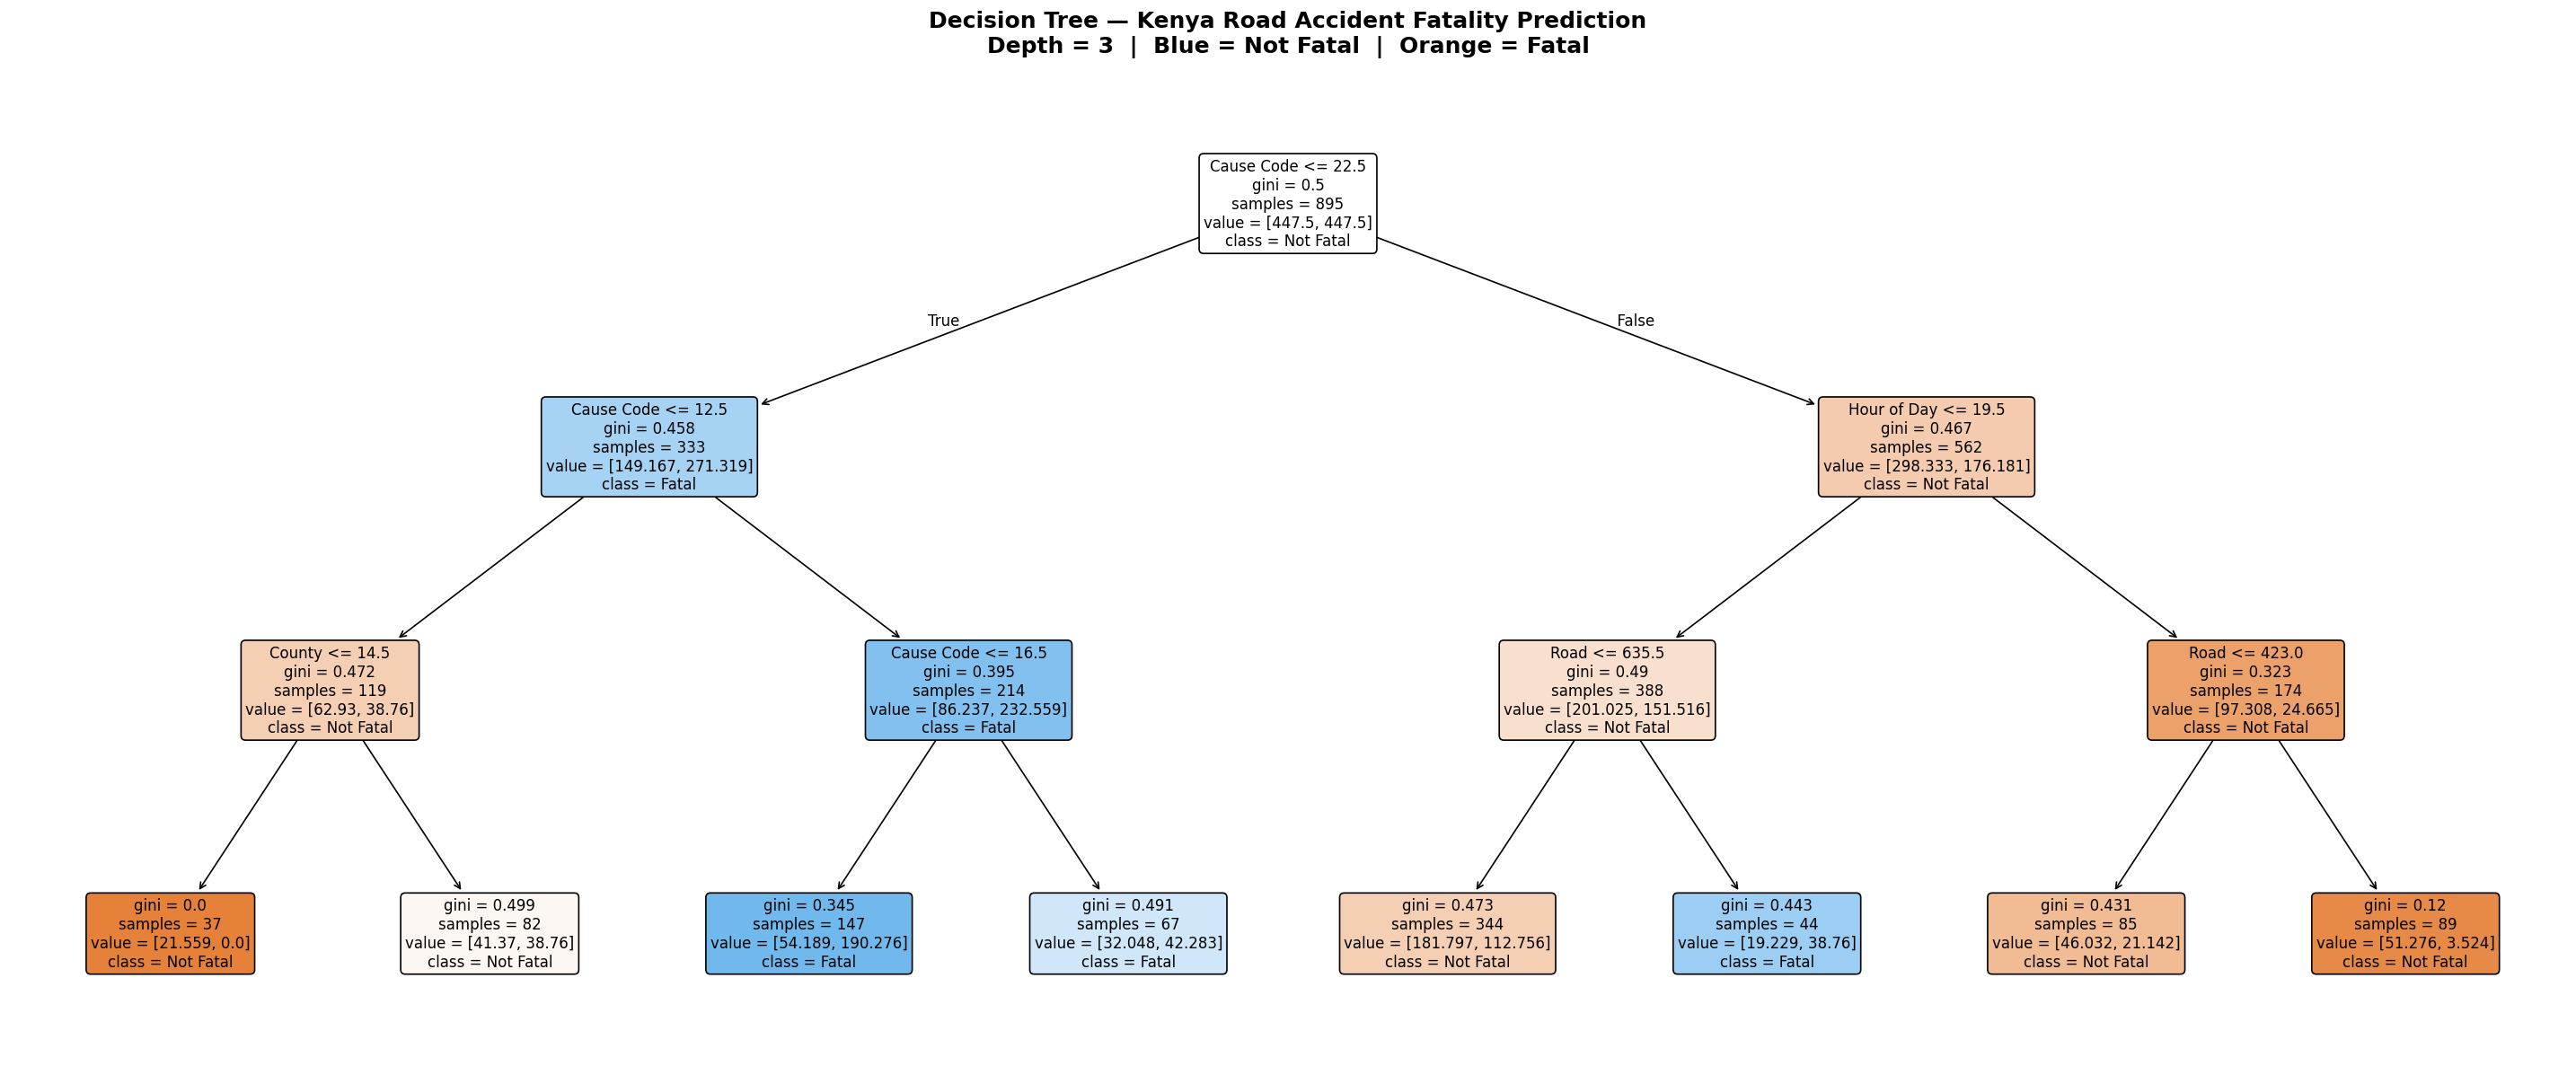

Tree diagram saved


In [6]:
# Visualize the shallow tree — easiest to read and
# most useful for presenting to non-technical audience

fig, ax = plt.subplots(figsize=(24, 10))

plot_tree(
    dt_shallow,
    feature_names = feature_names,
    class_names   = ['Not Fatal', 'Fatal'],
    filled        = True,
    rounded       = True,
    fontsize      = 10,
    impurity      = True,
    proportion    = False,
    ax            = ax
)

ax.set_title(
    'Decision Tree — Kenya Road Accident Fatality Prediction\n'
    'Depth = 3  |  Blue = Not Fatal  |  Orange = Fatal',
    fontsize=15, fontweight='bold', pad=20
)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'dt_tree_diagram.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Tree diagram saved")

In [7]:
# Print the decision rules in plain text
# This goes directly into your project report

print("="*55)
print("DECISION RULES — SHALLOW TREE (depth=3)")
print("Learned from Kenya NTSA Accident Data")
print("="*55)
rules = export_text(
    dt_shallow,
    feature_names = feature_names
)
print(rules)

DECISION RULES — SHALLOW TREE (depth=3)
Learned from Kenya NTSA Accident Data
|--- Cause Code <= 22.50
|   |--- Cause Code <= 12.50
|   |   |--- County <= 14.50
|   |   |   |--- class: 0
|   |   |--- County >  14.50
|   |   |   |--- class: 0
|   |--- Cause Code >  12.50
|   |   |--- Cause Code <= 16.50
|   |   |   |--- class: 1
|   |   |--- Cause Code >  16.50
|   |   |   |--- class: 1
|--- Cause Code >  22.50
|   |--- Hour of Day <= 19.50
|   |   |--- Road <= 635.50
|   |   |   |--- class: 0
|   |   |--- Road >  635.50
|   |   |   |--- class: 1
|   |--- Hour of Day >  19.50
|   |   |--- Road <= 423.00
|   |   |   |--- class: 0
|   |   |--- Road >  423.00
|   |   |   |--- class: 0



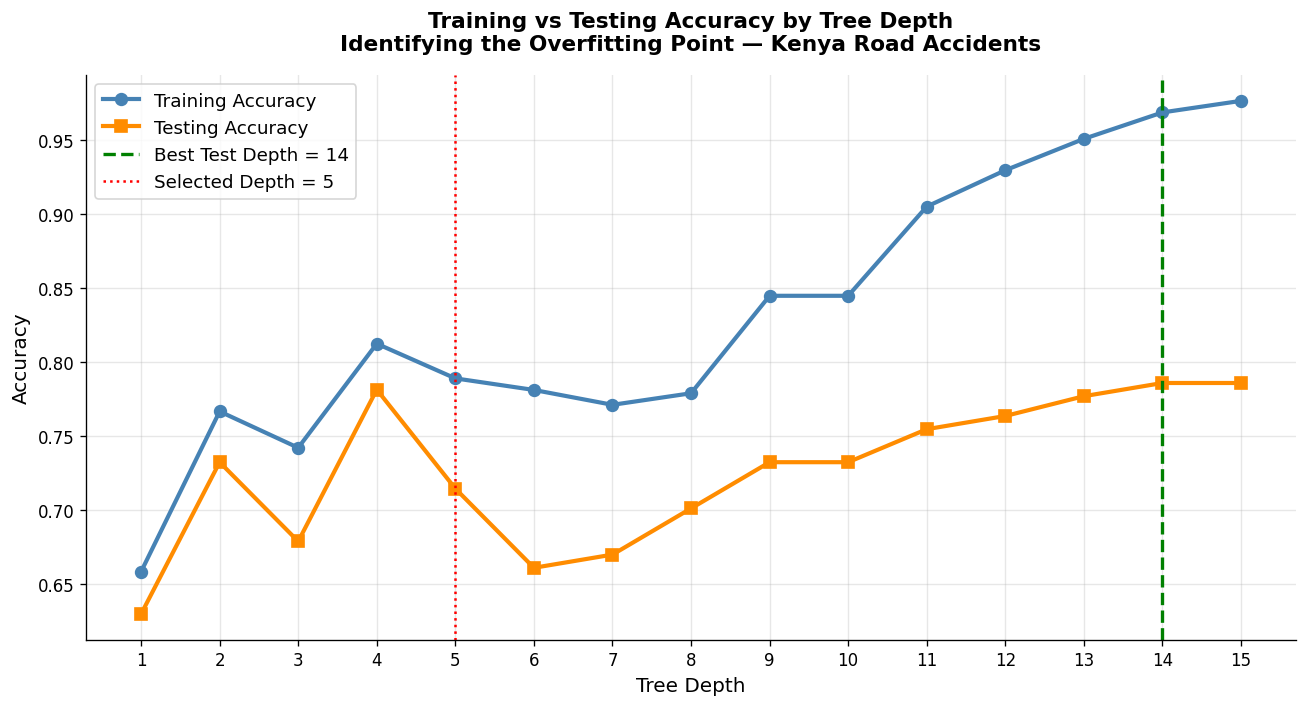

Best testing accuracy at depth = 14
Chart saved


In [8]:
# Show how accuracy changes as tree depth increases
# This is the overfitting demonstration

train_scores = []
test_scores  = []
depths       = range(1, 16)

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth    = depth,
        random_state = 42,
        class_weight = 'balanced'
    )
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test,  y_test))

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(depths, train_scores,
        'o-', color='steelblue', linewidth=2.5,
        markersize=7, label='Training Accuracy')
ax.plot(depths, test_scores,
        's-', color='darkorange', linewidth=2.5,
        markersize=7, label='Testing Accuracy')

# Mark optimal depth
best_depth = test_scores.index(max(test_scores)) + 1
ax.axvline(x=best_depth, color='green',
           linestyle='--', linewidth=2,
           label=f'Best Test Depth = {best_depth}')
ax.axvline(x=5, color='red',
           linestyle=':', linewidth=1.5,
           label='Selected Depth = 5')

ax.set_title(
    'Training vs Testing Accuracy by Tree Depth\n'
    'Identifying the Overfitting Point — '
    'Kenya Road Accidents',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Tree Depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(list(depths))

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'dt_overfitting_curve.png'),
            bbox_inches='tight')
plt.show()
print(f"Best testing accuracy at depth = {best_depth}")
print("Chart saved")

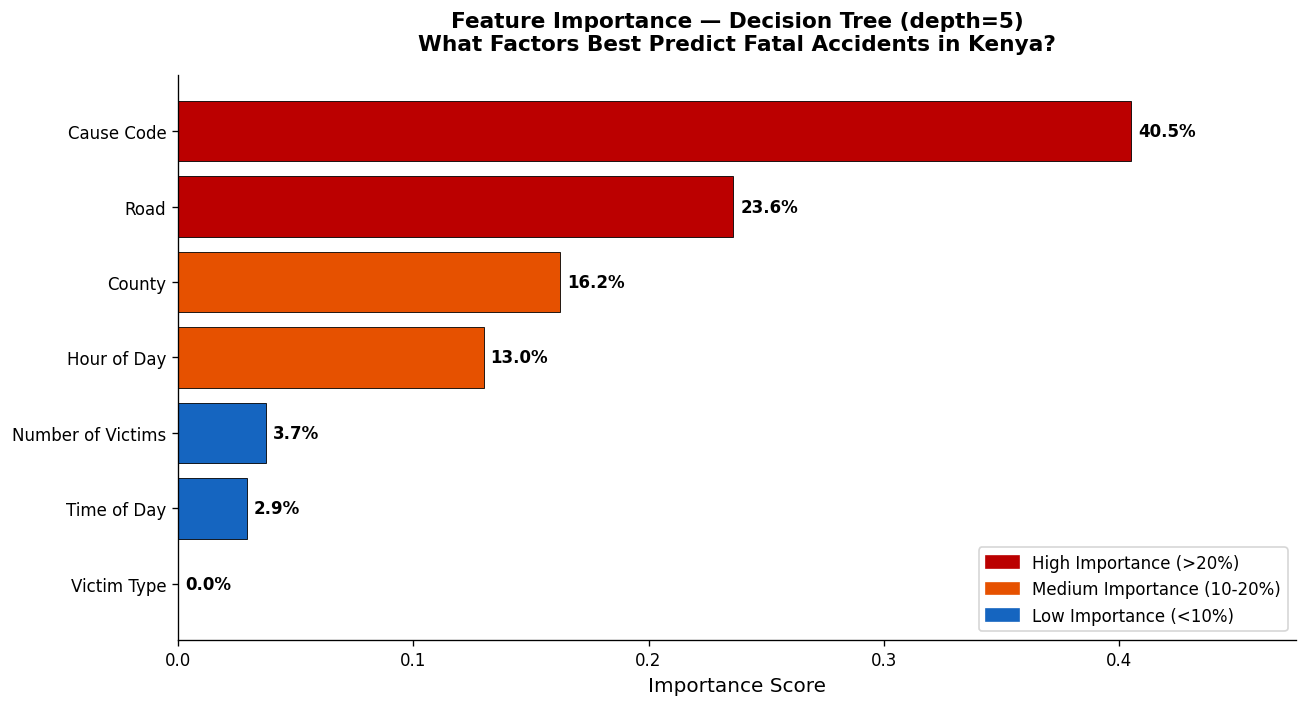

Chart saved


In [9]:
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': dt_medium.feature_importances_
}).sort_values('Importance', ascending=True)

# Colour by importance level
colors = []
for val in importance_df['Importance']:
    if val >= 0.20:
        colors.append('#BB0000')    # high — red
    elif val >= 0.10:
        colors.append('#E65100')    # medium — orange
    else:
        colors.append('#1565C0')    # low — blue

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors, edgecolor='black',
    linewidth=0.5
)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height()/2,
        f'{val*100:.1f}%', va='center',
        fontsize=10, fontweight='bold'
    )

ax.set_title(
    'Feature Importance — Decision Tree (depth=5)\n'
    'What Factors Best Predict Fatal Accidents in Kenya?',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, importance_df['Importance'].max() + 0.07)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#BB0000', label='High Importance (>20%)'),
    Patch(color='#E65100', label='Medium Importance (10-20%)'),
    Patch(color='#1565C0', label='Low Importance (<10%)')
]
ax.legend(handles=legend, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'dt_feature_importance.png'),
            bbox_inches='tight')
plt.show()
print("Chart saved")

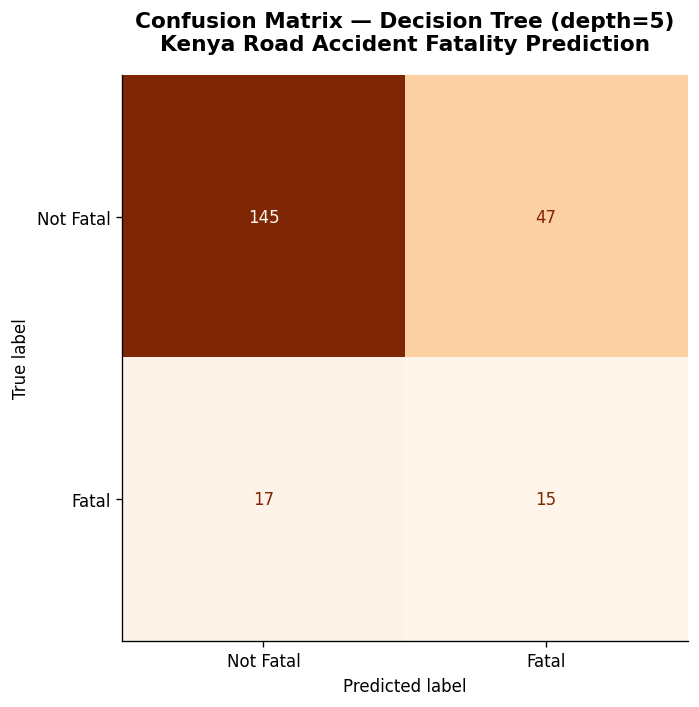

Confusion Matrix Breakdown:
  Correctly predicted Not Fatal : 145
  Correctly predicted Fatal     : 15
  False alarms                  : 47
  Missed fatals                 : 17


In [10]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Not Fatal', 'Fatal']
)
disp.plot(cmap='Oranges', colorbar=False, ax=ax)

ax.set_title(
    'Confusion Matrix — Decision Tree (depth=5)\n'
    'Kenya Road Accident Fatality Prediction',
    fontsize=13, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'dt_confusion_matrix.png'),
            bbox_inches='tight')
plt.show()

print("Confusion Matrix Breakdown:")
print(f"  Correctly predicted Not Fatal : {tn}")
print(f"  Correctly predicted Fatal     : {tp}")
print(f"  False alarms                  : {fp}")
print(f"  Missed fatals                 : {fn}")

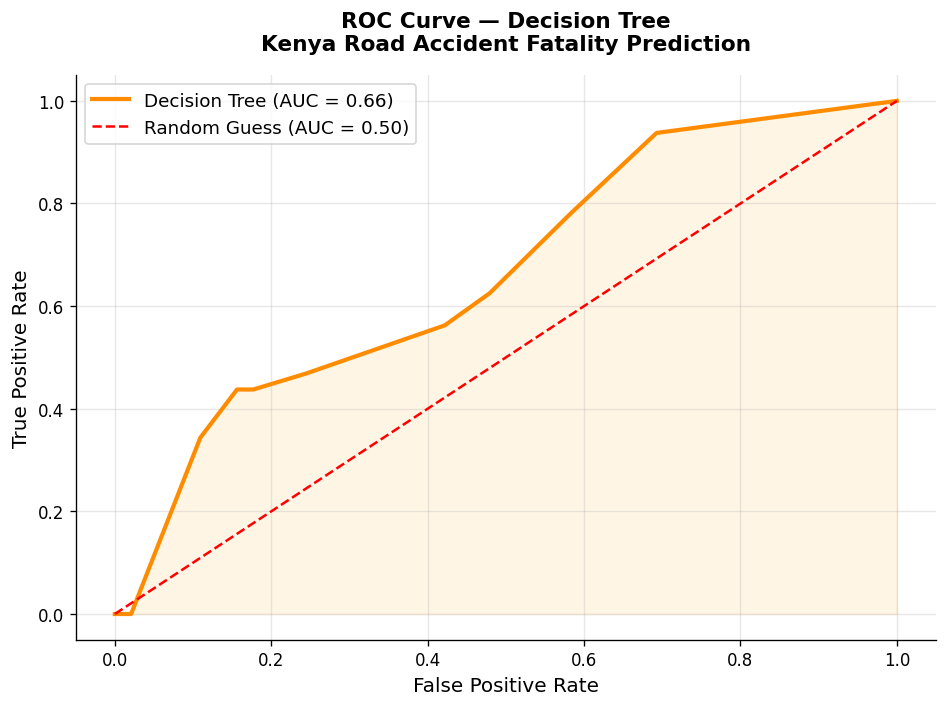

AUC Score: 0.6636
Chart saved


In [11]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr,
        color='darkorange', linewidth=2.5,
        label=f'Decision Tree (AUC = {auc:.2f})')
ax.plot([0, 1], [0, 1],
        color='red', linewidth=1.5,
        linestyle='--', label='Random Guess (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='orange')

ax.set_title(
    'ROC Curve — Decision Tree\n'
    'Kenya Road Accident Fatality Prediction',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS,
            'dt_roc_curve.png'),
            bbox_inches='tight')
plt.show()
print(f"AUC Score: {auc:.4f}")
print("Chart saved")

In [12]:
def predict_with_tree(hour, county, cause,
                      victim, time_of_day,
                      road, num_victims):
    try:
        input_data = pd.DataFrame([{
            'hour'           : hour,
            'county_encoded' : le_county.transform(
                                [county])[0],
            'cause_encoded'  : le_cause.transform(
                                [str(cause)])[0],
            'victim_encoded' : le_victim.transform(
                                [victim])[0],
            'time_encoded'   : le_time.transform(
                                [time_of_day])[0],
            'road_encoded'   : le_road.transform(
                                [road])[0],
            'num_victims'    : num_victims
        }])

        prediction  = dt_medium.predict(input_data)[0]
        probability = dt_medium.predict_proba(
                          input_data)[0][1]

        if probability >= 0.75:   risk = "CRITICAL RISK"
        elif probability >= 0.50: risk = "HIGH RISK"
        elif probability >= 0.25: risk = "MEDIUM RISK"
        else:                     risk = "LOW RISK"

        print("="*52)
        print("  DECISION TREE — FATALITY PREDICTION")
        print("="*52)
        print(f"  County       : {county}")
        print(f"  Time         : {hour:02d}:00 ({time_of_day})")
        print(f"  Road         : {road}")
        print(f"  Cause Code   : {cause}")
        print(f"  Victim Type  : {victim}")
        print(f"  Num Victims  : {num_victims}")
        print("-"*52)
        print(f"  Fatal Prob   : {probability*100:.1f}%")
        print(f"  Prediction   : "
              f"{'FATAL' if prediction==1 else 'NOT FATAL'}")
        print(f"  Risk Level   : {risk}")
        print("="*52)

    except ValueError as e:
        print(f"Input error: {e}")
        print("Check values exist in training data")

# ── Test with a scenario ─────────────────────────────
predict_with_tree(
    hour        = 22,
    county      = 'NAIROBI',
    cause       = '10',
    victim      = 'Motorcyclist',
    time_of_day = 'Night',
    road        = 'NAKURU-NAIROBI',
    num_victims = 1
)

  DECISION TREE — FATALITY PREDICTION
  County       : NAIROBI
  Time         : 22:00 (Night)
  Road         : NAKURU-NAIROBI
  Cause Code   : 10
  Victim Type  : Motorcyclist
  Num Victims  : 1
----------------------------------------------------
  Fatal Prob   : 0.0%
  Prediction   : NOT FATAL
  Risk Level   : LOW RISK


In [13]:
# Get scores for all three trees
shallow_f1  = f1_score(
    y_test, dt_shallow.predict(X_test), zero_division=0)
medium_f1   = f1_score(
    y_test, dt_medium.predict(X_test),  zero_division=0)
full_f1     = f1_score(
    y_test, dt_full.predict(X_test),    zero_division=0)

shallow_auc = roc_auc_score(
    y_test, dt_shallow.predict_proba(X_test)[:,1])
medium_auc  = roc_auc_score(
    y_test, dt_medium.predict_proba(X_test)[:,1])
full_auc    = roc_auc_score(
    y_test, dt_full.predict_proba(X_test)[:,1])

print("="*55)
print("NOTEBOOK 6 COMPLETE — DECISION TREE")
print("="*55)
print()
print(f"{'Model':<25} {'F1 Score':>10} {'AUC':>10}")
print("-"*45)
print(f"{'Shallow (depth=3)':<25} {shallow_f1:>10.4f} "
      f"{shallow_auc:>10.4f}")
print(f"{'Medium  (depth=5)':<25} {medium_f1:>10.4f} "
      f"{medium_auc:>10.4f}")
print(f"{'Full    (no limit)':<25} {full_f1:>10.4f} "
      f"{full_auc:>10.4f}")
print()
print("Primary model     : Medium Tree (depth=5)")
print(f"F1 Score          : {f1:.4f}")
print(f"AUC-ROC           : {auc:.4f}")
print()
print("Charts saved:")
print("  dt_tree_diagram.png")
print("  dt_overfitting_curve.png")
print("  dt_feature_importance.png")
print("  dt_confusion_matrix.png")
print("  dt_roc_curve.png")
print()
print("Next → Notebook 7: Random Forest")

NOTEBOOK 6 COMPLETE — DECISION TREE

Model                       F1 Score        AUC
---------------------------------------------
Shallow (depth=3)             0.3571     0.7124
Medium  (depth=5)             0.3191     0.6636
Full    (no limit)            0.2000     0.5365

Primary model     : Medium Tree (depth=5)
F1 Score          : 0.3191
AUC-ROC           : 0.6636

Charts saved:
  dt_tree_diagram.png
  dt_overfitting_curve.png
  dt_feature_importance.png
  dt_confusion_matrix.png
  dt_roc_curve.png

Next → Notebook 7: Random Forest
